# Simulación Variables macroscópicas

In [5]:
using LinearAlgebra
using SpecialFunctions
using Distributions
using Random
using Plots
using LaTeXStrings
using StaticArrays

## Matrices correspondientes a los subgrupos uniparamétricos

In [60]:
function K(θ::Float64)
    return @SMatrix [exp(im * θ/2)  0.0+0.0im; 
                     0.0+0.0im    exp(-im * θ/2)]
end

function N(x::Float64)
    return @SMatrix [1.0 - im*x/2   im*x/2; 
                     -im*x/2        1.0 + im*x/2]
end


function A(t::Float64)
    return @SMatrix [cosh(t)  sinh(t);
                     sinh(t)  cosh(t)]
end

A (generic function with 1 method)

Si 
$$
 \lambda_\pm = \frac{\tau \pm \sqrt{\tau^2-4e^{-\frac{\sigma_\varphi^2}{2}}}}{2}, \quad \tau =1+\frac{\sigma_\nu^2}{2}+\left(1-\frac{\sigma_\nu^2}{2}\right)e^{-\frac{\sigma_\varphi^2}{2}}
$$

Entonces 

$$
    \langle T^{-1}\rangle =\langle \lambda+1\rangle=\frac{1}{2}\left(\frac{\lambda_+^j-\lambda_-^j}{\lambda_+ - \lambda_-}\left(1+\frac{\sigma_\nu^2}{2}\right)-e^{-\frac{\sigma_\varphi^2}{2}}\frac{\lambda_+^{j-1}-\lambda_-^{j-1}}{\lambda_+ - \lambda_-}+1\right)
$$

Así la función para obtener el promedio teórico de $1/T$ es 

In [2]:
function avg_T_inv(σ_ν, σ_ϕ, N)
    τ=1+σ_ν^2/2+(1-σ_ν^2/2)exp(-σ_ϕ^2/2)
    λ_p=τ/2+0.5*√(τ^2-4exp(-σ_ϕ^2/2))
    λ_m=τ/2-0.5*√(τ^2-4exp(-σ_ϕ^2/2))
    return 0.5*((λ_p^N-λ_m^N)/(λ_p-λ_m) * (1+σ_ν^2/2) - exp(-σ_ϕ^2/2) * (λ_p^(N-1)-λ_m^(N-1))/(λ_p-λ_m) +1)
end

avg_T_inv (generic function with 1 method)

In [47]:
avg_T_inv(sqrt(4/100), sqrt(0.01/100), 100)

2.0016652506838

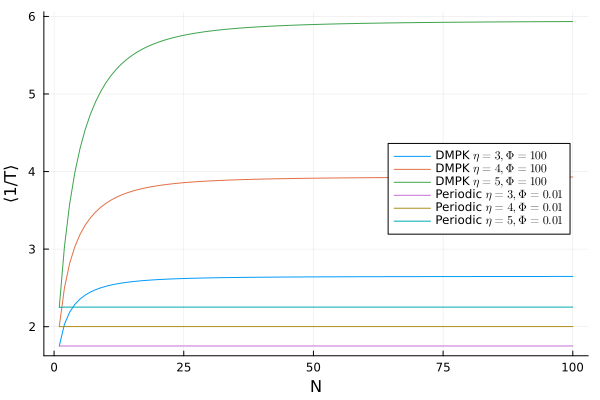

In [136]:
a(N)=avg_T_inv(sqrt(3/N), sqrt(100/N),N)
f(N)=avg_T_inv(sqrt(4/N), sqrt(100/N),N)
g(N)=avg_T_inv(sqrt(5/N), sqrt(100/N),N)
a_p(N)=avg_T_inv(sqrt(3/N), sqrt(0.01/N),N)
f_p(N)=avg_T_inv(sqrt(4/N), sqrt(0.01/N),N)
g_p(N)=avg_T_inv(sqrt(5/N), sqrt(0.01/N),N)
gr()
plot(range(1, 100, length=100), a, label="DMPK \$ η=3, Φ=100\$", legend=:right)
plot!(range(1, 100, length=100), f, label="DMPK \$ η=4, Φ=100\$")
plot!(range(1, 100, length=100), g, label="DMPK \$ η=5, Φ=100\$")
plot!(range(1, 100, length=100), a_p, label="Periodic \$ η=3, Φ=0.01\$")
plot!(range(1, 100, length=100), f_p, label="Periodic \$ η=4, Φ=0.01\$")
plot!(range(1, 100, length=100), g_p, label="Periodic \$ η=5, Φ=0.01\$")
xlabel!("N")
ylabel!("⟨1/T⟩")
#ylims!(1,2)

Y la expresión asintótica para las variables macroscópicas
$N\sigma_\nu^2=\eta$ y $N\sigma_\varphi^2=\Phi$
 es

In [49]:
function macro_avg_T_inv(η, Φ)
    sq_term = sqrt(4*η*Φ + Φ^2)
    val = 0.5 * (1 + exp(-Φ/4) * (cosh(sq_term/4) + ((2*η + Φ) / sq_term) * sinh(sq_term/4)))
    return val
end

macro_avg_T_inv (generic function with 2 methods)

In [ ]:
macro_avg_T_inv(4, 0.01)

2.0016654175589315

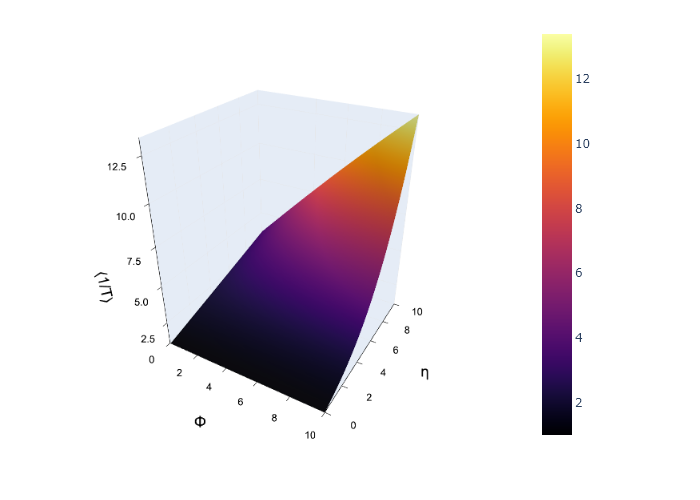

In [52]:
plotlyjs() #imagen interactiva
Φ_vals = range(0.0, stop=10.0, length=200)
η_vals = range(0.0, stop=10.0, length=200)

# build Z as a matrix: rows -> η, cols -> Φ
Z = [ macro_avg_T_inv(η, Φ) for η in η_vals, Φ in Φ_vals ]

surface(Φ_vals, η_vals, Z;
    xlabel="Φ", ylabel="η", zlabel="⟨1/T⟩")

A continuación se presenta una función de la diferencia entre la exptresión teórica y la asintótica

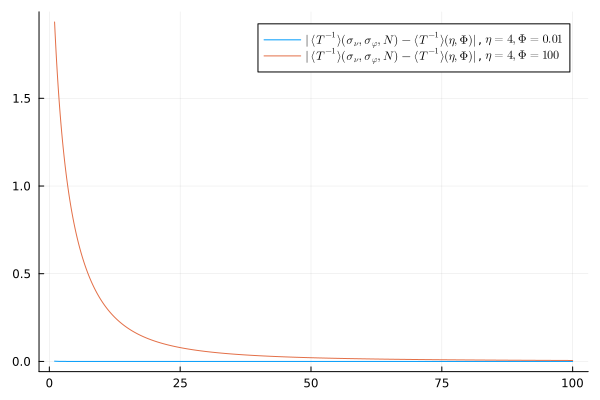

In [57]:
function dif(η, Φ, N)
    return abs(avg_T_inv(sqrt(η/N),sqrt(Φ/N),N)-macro_avg_T_inv(η, Φ))
end
et=4
et_2=4
ph=0.01
ph_2=100
y(N)=dif(et,ph,N)
y_2(N)=dif(et_2,ph_2,N)
gr()
plot(range(1, 100, length=1000), y, label="\$|⟨T^{-1}⟩(σ_ν,σ_ϕ,N) - ⟨T^{-1}⟩(η, Φ)|\$, \$η=$et, Φ=$ph\$")
plot!(range(1, 100, length=1000), y_2, label="\$|⟨T^{-1}⟩(σ_ν,σ_ϕ,N) - ⟨T^{-1}⟩(η, Φ)|\$, \$η=$et_2, Φ=$ph_2\$")

In [ ]:
"""
    ensemble(n_matrices::Int, n_samples::Int, component::Tuple{Int,Int}, η::Float64, Φ::Float64)

Genera una muestra de `n_samples` matrices de transferencia correspondientes a una cadena de deltas,
el  numero de deltas en la cadena es `n_matrices`. Finalmente extrae la componente `component`.

Los elaboenes en la cadena de deltas tienen dos parametros, la "fuerza adiensional" y la "distancia 
adiimensional". Para un sistema con desorden estos parámetros se toman de una distribución normal 
cuya media hace que las matrices correspondientes esten centradas en la identidad.

Las varianzas tienen una dependencia inversa con el número de eslabones en la cadena.

# Returns
- `Vector{ComplexF64}`: Un vector de `n_samples` numeros complejos, cada uno representando el valor 
de la componente de la matriz despues de una realización.

# Examples
```julia
# Genera 1000 muestras de la componente (1,1)
samples = ensemble(10, 1000, (1,1), 0.1, 0.05)
mean(abs2.(samples))  # Promedio aproximado del ensamble para la inversa de la probabilidad de trnasmisión

"""
function ensemble(n_matrices::Int, n_samples::Int, component::Tuple{Int,Int}, η::Float64, Φ::Float64)
    
    samples = Vector{ComplexF64}(undef, n_samples)
    
    σ_ν = sqrt(η / n_matrices) 
    σ_ϕ = sqrt(Φ / n_matrices)

    row, col = component[1], component[2]
    
    for i in 1:n_samples
        M = @SMatrix [1.0+0.0im 0.0+0.0im; 
                      0.0+0.0im 1.0+0.0im]              
        for _ in 1:n_matrices
            x = rand(Normal(0, σ_ν))
            θ = rand(Normal(2*π, σ_ϕ))
            M = M * (K(θ) * N(x)) 
        end
        samples[i] = M[row, col]
    end
    
    return samples
end

ensemble

In [62]:
prueba=ensemble(100, 10000, (1,1), 4.0, 0.01)
mean(abs2.(c_2))

2.0014433474465703

In [71]:
η_p = 4.0
Φ_p = 0.01
N_valores = 2:2:240
n_samples = 10_000
# Run simulation
means = Vector{Float64}(undef, length(N_valores))
for (i, N_dis) in enumerate(N_valores)
    #println("Simulating N = $N_dis...") 
    M_11 = ensemble(N_dis, n_samples, (1, 1), η_p, Φ_p)
    means[i] = mean(abs2, M_11)
end

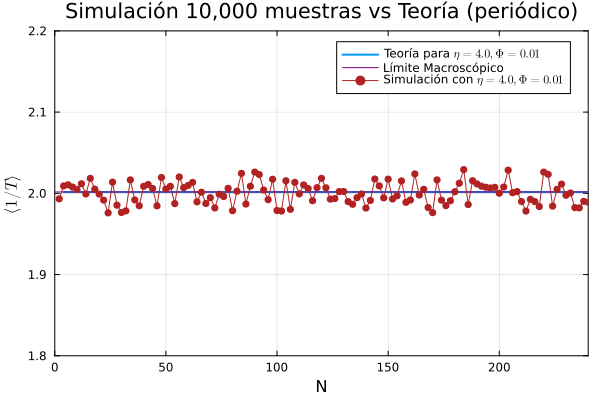

In [ ]:
gr()
N_vals = range(0, 400, length=100)
asint=macro_avg_T_inv(η_p, Φ_p)
theory_line(N) = avg_T_inv(sqrt(η_p/N), sqrt(Φ_p/N), N)

plot(N_vals, theory_line, title="Simulación 10,000 muestras vs Teoría (periódico)", label="Teoría para \$η=$η_p, Φ=$Φ_p\$", framestyle=:box,lw=:2)
hline!([asint], label="Límite Macroscópico", color="purple")
plot!(N_valores, means, marker=:circle, xlabel="N", ylabel=L"⟨1/T⟩", label="Simulación con \$η=$η_p, Φ=$Φ_p\$",color=:firebrick, markerstrokewidth=0, legend=:topright)
xlims!(0,240)
ylims!(1.8,2.2)
#savefig("macroscopic.png")

In [ ]:
η_2p = 4.0
Φ_2p = 100.0

means_2 = Vector{Float64}(undef, length(N_valores))
for (i, N_dis) in enumerate(N_valores)
    #println("Simulating N = $N_dis...") 
    M_11 = ensemble(N_dis, n_samples, (1, 1), η_2p, Φ_2p)
    means_2[i] = mean(abs2, M_11)
end

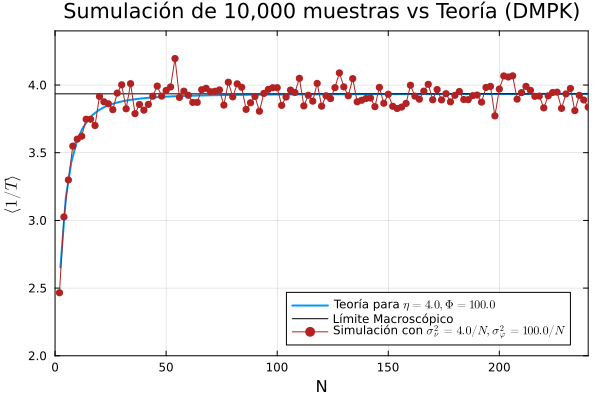

In [ ]:
gr()
N_vals = range(0, 241, length=100)
asint_2=macro_avg_T_inv(η_2p, Φ_2p)
theory_line_2(N) = avg_T_inv(sqrt(η_2p/N), sqrt(Φ_2p/N), N)

plot(N_vals, theory_line_2,title="Sumulación de 10,000 muestras vs Teoría (DMPK)", label="Teoría para \$η=$η_2p, Φ=$Φ_2p\$", framestyle=:box,lw=:2)
hline!([asint_2], label="Límite Macroscópico", color="black")
plot!(N_valores, means_2, marker=:circle, xlabel="N", ylabel=L"⟨1/T⟩", label="Simulación con \$σ_ν^2=$η_2p/N, σ_ϕ^2=$Φ_2p/N\$",color=:firebrick, markerstrokewidth=0, legend=:bottomright)
xlims!(0,240)
ylims!(2.0,4.4)
#savefig("macroscopic2.png")

De regimen aislante $T<<1$, al balistico $T \approx 1$

In [126]:
Φ1 = 0.01
N_deltas = 200
η_vals=range(0.4,12,100)

means_log_T_inv = Vector{Float64}(undef, length(η_vals))
for (i, η) in enumerate(η_vals)
    M_11 = ensemble(N_deltas, 10_000, (1, 1), η, Φ1)
    means_log_T_inv[i] = mean(x -> log(abs2(x)), M_11)
end

In [127]:
means_T_inv = Vector{Float64}(undef, length(η_vals))
for (i, η) in enumerate(η_vals)
    M_11 = ensemble(N_deltas, 10_000, (1, 1), η, Φ1)
    means_T_inv[i] = mean(abs2, M_11)
end

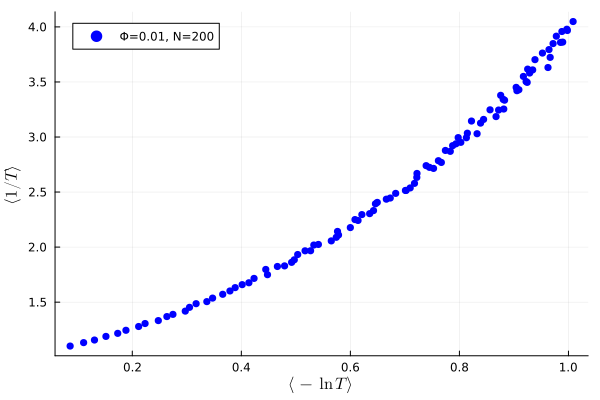

In [128]:
scatter(means_log_T_inv, means_T_inv,label="Φ=0.01, N=200", xlabel=L"⟨-\ln T\, ⟩", ylabel=L"⟨1/T⟩" ,color=:blue, markerstrokewidth=0)

In [137]:
function compute_means(Φ, N, η_vals)
    means_log_T_inv = Vector{Float64}(undef, length(η_vals))
    means_T_inv = Vector{Float64}(undef, length(η_vals))
    for (i, η) in enumerate(η_vals)
        M_11 = ensemble(N, 10_000, (1, 1), η, Φ)
        means_log_T_inv[i] = mean(x -> log(abs2(x)), M_11)
        means_T_inv[i] = mean(abs2, M_11)
    end
    return means_log_T_inv, means_T_inv
end

η_vals_5 = range(0.1, 10, 100)


# Compute for different parameters
log1, t1 = compute_means(5.0, 100, η_vals)
log2, t2 = compute_means(5.0, 200, η_vals)
log3, t3 = compute_means(10.0, 100, η_vals)
log4, t4 = compute_means(10.0, 200, η_vals)

([0.09691951138395638, 0.12464984237158151, 0.14967844828348398, 0.17801941964542603, 0.20190446253466335, 0.2304555444600861, 0.25094575370964767, 0.27501914060357463, 0.2945777127491739, 0.3246743698729568  …  1.6870604195139822, 1.689101293251964, 1.7070415065766344, 1.685184003082241, 1.721444447605794, 1.7400015810008633, 1.7417318342312742, 1.750919612255746, 1.7801620533376277, 1.7873700644299344], [1.1075586090393645, 1.1421978665604997, 1.1762923842795798, 1.2165921324095303, 1.2514712761115305, 1.2966849536252778, 1.330760708818481, 1.3712686603749307, 1.4085862979643808, 1.4625460645834336  …  15.708171942731848, 17.042044979504787, 16.882142257244773, 15.92377897278782, 17.737429740784428, 18.52865312390293, 18.466858394841918, 18.00776849439456, 19.660575690625368, 21.053918023326226])

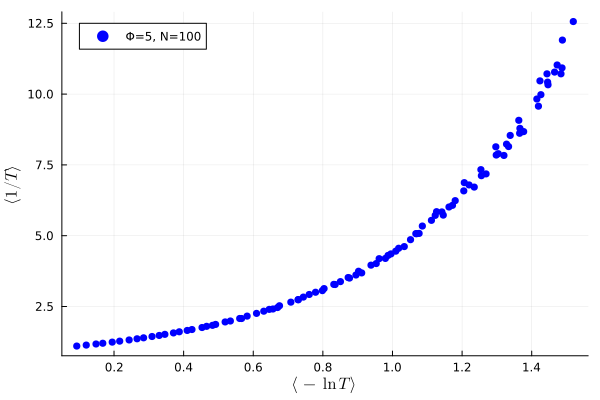

In [138]:
scatter(log1, t1, label="Φ=5, N=100", color=:blue, markerstrokewidth=0)
xlabel!(L"⟨-\ln T\, ⟩")
ylabel!(L"⟨1/T⟩")

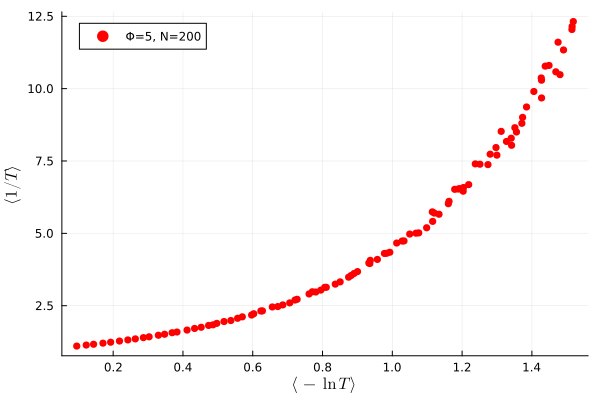

In [139]:
scatter(log2, t2, label="Φ=5, N=200", color=:red, markerstrokewidth=0)
xlabel!(L"⟨-\ln T\, ⟩")
ylabel!(L"⟨1/T⟩")

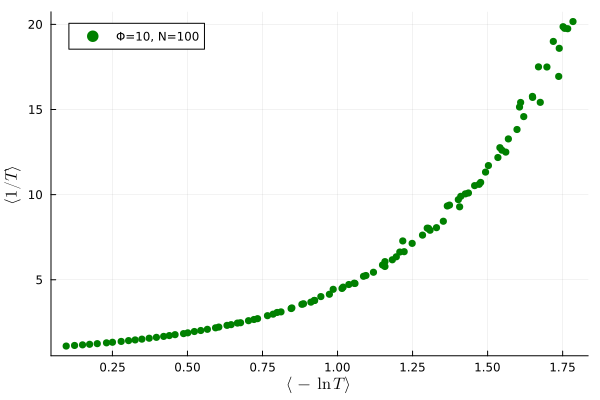

In [140]:
scatter(log3, t3, label="Φ=10, N=100", color=:green, markerstrokewidth=0)
xlabel!(L"⟨-\ln T\, ⟩")
ylabel!(L"⟨1/T⟩")

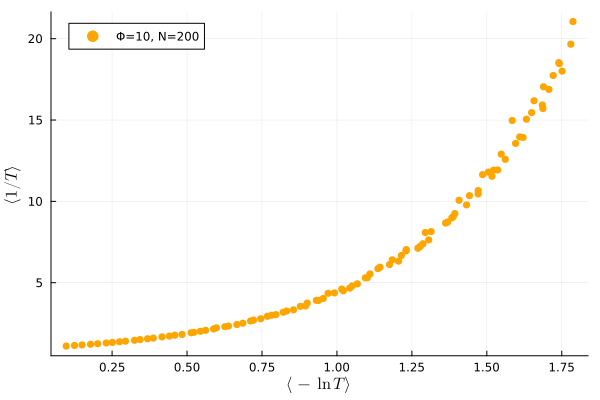

In [141]:
scatter(log4, t4, label="Φ=10, N=200", color=:orange, markerstrokewidth=0)
xlabel!(L"⟨-\ln T\, ⟩")
ylabel!(L"⟨1/T⟩")

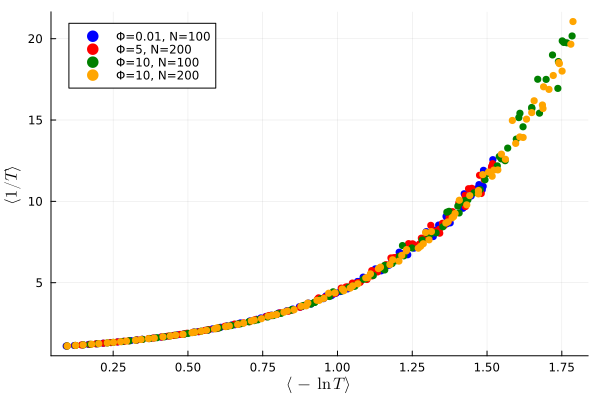

In [142]:
# Plot all on the same scatter plot
scatter(log1, t1, label="Φ=0.01, N=100", color=:blue, markerstrokewidth=0)
scatter!(log2, t2, label="Φ=5, N=200", color=:red, markerstrokewidth=0)
scatter!(log3, t3, label="Φ=10, N=100", color=:green, markerstrokewidth=0)
scatter!(log4, t4, label="Φ=10, N=200", color=:orange, markerstrokewidth=0)
xlabel!(L"⟨-\ln T\, ⟩")
ylabel!(L"⟨1/T⟩")